In [1]:
import sys
!{sys.executable} -m pip install -q torch matplotlib scikit-learn numpy pandas

Epoch 50 | Loss: 1.0694
Epoch 100 | Loss: 1.0455
Epoch 150 | Loss: 1.0341


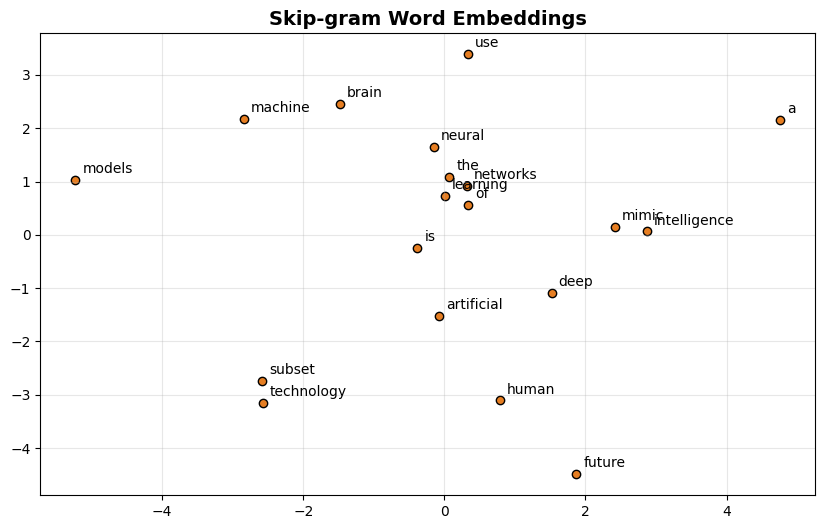


CONCEPTUAL COMPARISON
   Feature                   CBOW              Skip-gram
     Input Context Words (Summed)     Single Target Word
    Output     Single Target Word Multiple Context Words
  Best For Frequent Words / Speed  Rare Words / Accuracy
Complexity                  Lower                 Higher


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# --- 1. Data Setup ---
corpus = """
deep learning models use neural networks
neural networks mimic the human brain
artificial intelligence is the future of technology
machine learning is a subset of artificial intelligence
"""

tokens = corpus.lower().split()
vocab = sorted(list(set(tokens)))
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# Prepare Skip-gram Pairs: (Center, Context)
# "deep learning models" -> (learning, deep), (learning, models)
data = []
for i in range(1, len(tokens) - 1):
    target = tokens[i]
    context = [tokens[i-1], tokens[i+1]]
    for w in context:
        data.append((target, w))

# --- 2. Skip-gram Model ---
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGram, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.embeddings(x)
        return self.linear(x)

# --- 3. Training ---
EMBED_DIM = 20
model = SkipGram(vocab_size, EMBED_DIM)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(150):
    total_loss = 0
    for target, context in data:
        t_idx = torch.tensor([word_to_ix[target]])
        c_idx = torch.tensor([word_to_ix[context]])
        
        optimizer.zero_grad()
        output = model(t_idx)
        loss = criterion(output, c_idx)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(data):.4f}")

# Extract Vectors
skipgram_vectors = model.embeddings.weight.data.numpy()

# --- 4. Comparison Visualization ---
pca = PCA(n_components=2)
coords = pca.fit_transform(skipgram_vectors)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], color='#e67e22', edgecolors='k')

for i, word in enumerate(vocab):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points')

plt.title('Skip-gram Word Embeddings', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Conceptual Comparison Table ---
comparison = {
    "Feature": ["Input", "Output", "Best For", "Complexity"],
    "CBOW": ["Context Words (Summed)", "Single Target Word", "Frequent Words / Speed", "Lower"],
    "Skip-gram": ["Single Target Word", "Multiple Context Words", "Rare Words / Accuracy", "Higher"]
}
print("\n" + "="*50)
print("CONCEPTUAL COMPARISON")
print("="*50)
print(pd.DataFrame(comparison).to_string(index=False))